# Alpamayo-R1 Demo

This notebook will load some example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and run the Alpamayo-R1 model on it, producing and visualizing output trajectories and associated reasoning traces.

In [46]:
import copy
import numpy as np
import mediapy as mp
import pandas as pd

import torch
from alpamayo_r1.models.alpamayo_r1 import AlpamayoR1
from alpamayo_r1.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo_r1.load_nuscenes import NuScenesDataInterface, load_nuscenes
from alpamayo_r1 import helper

### Load model and construct data preprocessor

In [47]:
model = AlpamayoR1.from_pretrained("nvidia/Alpamayo-R1-10B", dtype=torch.bfloat16).to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [48]:
import time

t_start_load = time.perf_counter()
clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
clip_id = clip_ids[7]
# clip_id = '030c760c-ae38-49aa-9ad8-f5650a545d26'

data = load_physical_aiavdataset(clip_id)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_load = time.perf_counter()
timing_load_ms = (t_end_load - t_start_load) * 1000.0
print(f"数据加载与预处理耗时: {timing_load_ms:.2f} ms")

seq length: torch.Size([1, 3006])
数据加载与预处理耗时: 6729.94 ms


In [49]:
def build_masked_inputs(data, keep_camera_index):
    """构建 masked 版本：仅保留 keep_camera_index 对应摄像头，其余置零。

    Args:
        data: 原始数据字典，包含 image_frames, camera_indices 等
        keep_camera_index: 要保留的摄像头索引

    Returns:
        data_m: masked 后的数据字典
        model_inputs_m: 可直接传入模型的输入字典
    """
    data_m = copy.deepcopy(data)
    keep_pos = (data_m["camera_indices"] == keep_camera_index).nonzero(as_tuple=True)[0].item()
    for i in range(data_m["image_frames"].shape[0]):
        if i != keep_pos:
            data_m["image_frames"][i] = torch.zeros_like(data_m["image_frames"][i])
    messages_m = helper.create_message(data_m["image_frames"].flatten(0, 1))
    inputs_m = processor.apply_chat_template(
        messages_m,
        tokenize=True,
        add_generation_prompt=False,
        continue_final_message=True,
        return_dict=True,
        return_tensors="pt",
    )
    model_inputs_m = {
        "tokenized_data": inputs_m,
        "ego_history_xyz": data_m["ego_history_xyz"],
        "ego_history_rot": data_m["ego_history_rot"],
    }
    model_inputs_m = helper.to_device(model_inputs_m, "cuda")
    return data_m, model_inputs_m

# Masked-30FOV: 仅保留 CAMERA_FRONT_TELE_30FOV (camera_index=6)
data_masked_30, model_inputs_masked_30 = build_masked_inputs(data, keep_camera_index=6)

# Masked-120FOV: 仅保留 CAMERA_FRONT_WIDE_120FOV (camera_index=1)
data_masked_120, model_inputs_masked_120 = build_masked_inputs(data, keep_camera_index=1)

print("Masked 数据构建完成")
print(f"  30FOV 保留位置: {(data['camera_indices'] == 6).nonzero(as_tuple=True)[0].item()}")
print(f"  120FOV 保留位置: {(data['camera_indices'] == 1).nonzero(as_tuple=True)[0].item()}")

Masked 数据构建完成
  30FOV 保留位置: 3
  120FOV 保留位置: 1


In [ ]:
# --- nuScenes 数据加载 ---
ndi = NuScenesDataInterface()
scene_name = "scene-0069"
data_nuscenes = load_nuscenes(scene_name, ndi=ndi)

# Full nuScenes (all cameras) model inputs
messages_ns = helper.create_message(data_nuscenes["image_frames"].flatten(0, 1))
inputs_ns = processor.apply_chat_template(
    messages_ns, tokenize=True, add_generation_prompt=False,
    continue_final_message=True, return_dict=True, return_tensors="pt",
)
model_inputs_nuscenes = {
    "tokenized_data": inputs_ns,
    "ego_history_xyz": data_nuscenes["ego_history_xyz"],
    "ego_history_rot": data_nuscenes["ego_history_rot"],
}
model_inputs_nuscenes = helper.to_device(model_inputs_nuscenes, "cuda")

# Masked nuScenes (CAM_FRONT only)
data_nuscenes_front, model_inputs_nuscenes_front = build_masked_inputs(data_nuscenes, keep_camera_index=1)
print("nuScenes 数据构建完成")

nuScenes 数据构建完成


### Model inference

In [51]:
def print_timing(label, extra, total_ms):
    vision_ms = float(extra.get("timing_vision_ms", float("nan")))
    cot_ms = float(extra.get("timing_cot_ms",
                   float(extra.get("timing_cot_s", float("nan"))) * 1000.0))
    traj_ms = float(extra.get("timing_traj_gen_ms",
                    float(extra.get("timing_traj_gen_s", float("nan"))) * 1000.0))
    print(f"\n--- {label} ---")
    print(f"  Vision Encoder: {vision_ms:.2f} ms")
    print(f"  CoT 推理:       {cot_ms:.2f} ms")
    print(f"  轨迹生成:       {traj_ms:.2f} ms")
    print(f"  总推理耗时:     {total_ms:.2f} ms")

if torch.cuda.is_available():
    torch.cuda.synchronize()

torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_infer = time.perf_counter()
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=2,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_infer = time.perf_counter()
timing_infer_ms = (t_end_infer - t_start_infer) * 1000.0

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])
print(f"\n数据加载与预处理: {timing_load_ms:.2f} ms")
print_timing("Original (4 Cameras)", extra, timing_infer_ms)

# --- Masked-30FOV 推理 ---
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_m30 = time.perf_counter()
    pred_xyz_m30, pred_rot_m30, extra_m30 = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs_masked_30),
        top_p=0.98, temperature=0.6, num_traj_samples=2,
        max_generation_length=256, return_extra=True,
    )
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_m30 = time.perf_counter()

print("\nCoC:", extra_m30["cot"][0])
print_timing("Masked-30FOV (Front Tele 30FOV Only)", extra_m30, (t_end_m30 - t_start_m30) * 1000)

# --- Masked-120FOV 推理 ---
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_m120 = time.perf_counter()
    pred_xyz_m120, pred_rot_m120, extra_m120 = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs_masked_120),
        top_p=0.98, temperature=0.6, num_traj_samples=2,
        max_generation_length=256, return_extra=True,
    )
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_m120 = time.perf_counter()

print("\nCoC:", extra_m120["cot"][0])
print_timing("Masked-120FOV (Front Wide 120FOV Only)", extra_m120, (t_end_m120 - t_start_m120) * 1000)

# --- nuScenes Full (all cameras) 推理 ---
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_ns_full = time.perf_counter()
    pred_xyz_ns_full, pred_rot_ns_full, extra_ns_full = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs_nuscenes),
        top_p=0.98, temperature=0.6, num_traj_samples=2,
        max_generation_length=256, return_extra=True,
    )
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_ns_full = time.perf_counter()

print("\nCoC:", extra_ns_full["cot"][0])
print_timing("nuScenes Full", extra_ns_full, (t_end_ns_full - t_start_ns_full) * 1000)

# --- nuScenes CAM_FRONT 推理 ---
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    t_start_ns = time.perf_counter()
    pred_xyz_ns, pred_rot_ns, extra_ns = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs_nuscenes_front),
        top_p=0.98, temperature=0.6, num_traj_samples=2,
        max_generation_length=256, return_extra=True,
    )
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end_ns = time.perf_counter()

print("\nCoC:", extra_ns["cot"][0])
print_timing("nuScenes CAM_FRONT", extra_ns, (t_end_ns - t_start_ns) * 1000)

Chain-of-Causation (per trajectory):
 [['Adapt speed for the right-hand curve ahead.'
  'Adapt speed for the right-hand curve ahead.']]

数据加载与预处理: 6729.94 ms

--- Original (4 Cameras) ---
  Vision Encoder: 218.80 ms
  CoT 推理:       885.11 ms
  轨迹生成:       118.49 ms
  总推理耗时:     1018.42 ms

CoC: [['Adapt speed for the right-hand curve ahead.'
  'Adapt speed for the right-hand curve ahead.']]

--- Masked-30FOV (Front Tele 30FOV Only) ---
  Vision Encoder: 217.47 ms
  CoT 推理:       881.94 ms
  轨迹生成:       118.53 ms
  总推理耗时:     1015.10 ms

CoC: [['Adapt speed for the right-hand curve ahead.'
  'Adapt speed for the right-hand curve ahead.']]

--- Masked-120FOV (Front Wide 120FOV Only) ---
  Vision Encoder: 217.61 ms
  CoT 推理:       882.19 ms
  轨迹生成:       118.40 ms
  总推理耗时:     1015.08 ms

CoC: [['Yield to the cross-traffic vehicle on the main road.'
  'Yield to the cross-traffic motorcycle because it has priority at the yield sign.']]

--- nuScenes Full ---
  Vision Encoder: 216.97 ms
  C

## Visualizing data and results

========== PhysicalAI-AV 数据集 ==========
=== 原始输入图像 ===


,,,
,,,
,,,
,,,

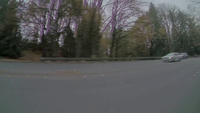
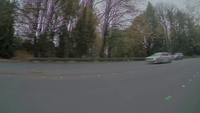
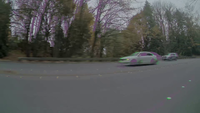
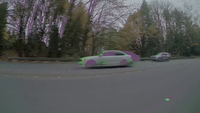
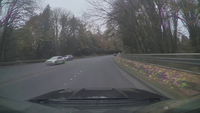
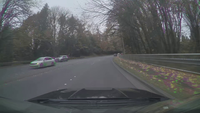
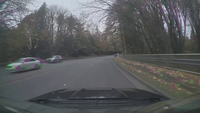
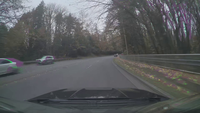
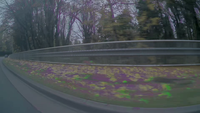
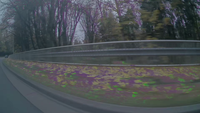
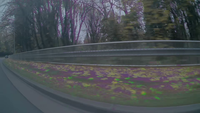
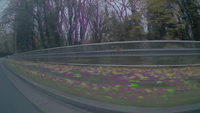
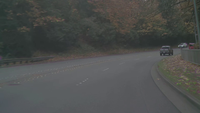
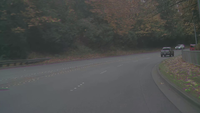
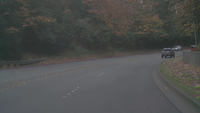
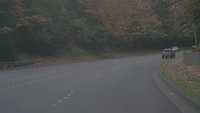

=== Masked-30FOV 输入图像 ===


,,,
,,,
,,,
,,,

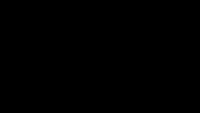
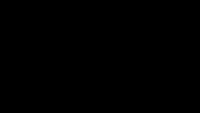
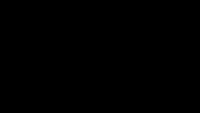
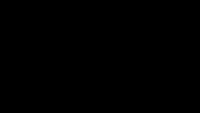
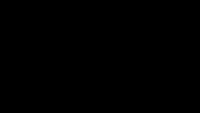
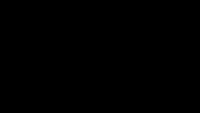
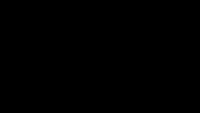
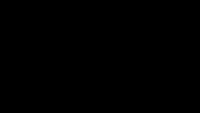
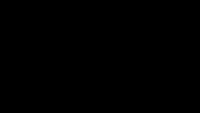
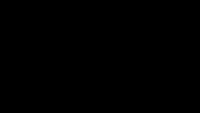
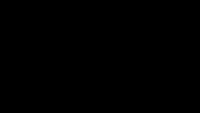
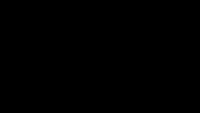
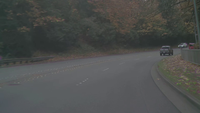
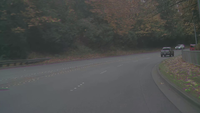
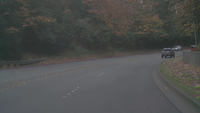
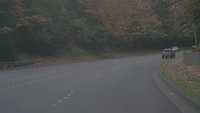

=== Masked-120FOV 输入图像 ===


,,,
,,,
,,,
,,,

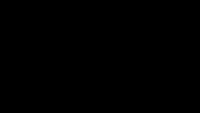
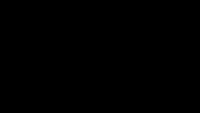
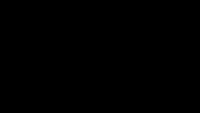
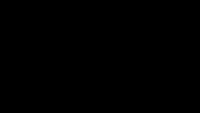
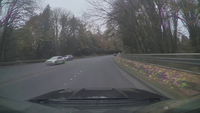
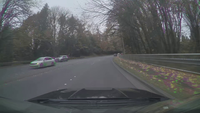
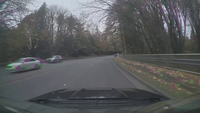
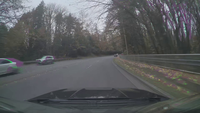
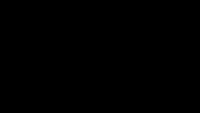
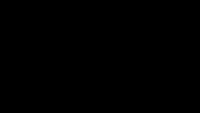
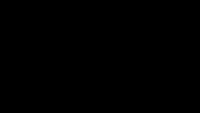
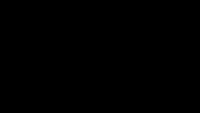
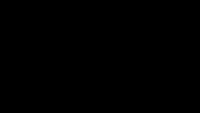
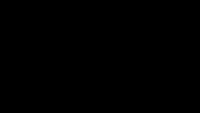
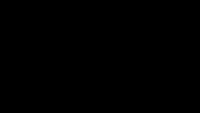
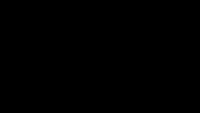


========== nuScenes 数据集 ==========
=== nuScenes Full 输入图像 ===


,,,
,,,
,,,
,,,

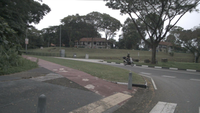
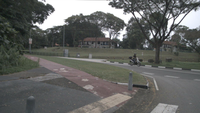
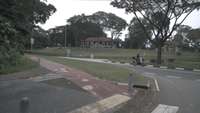
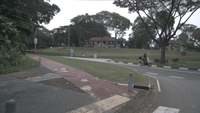
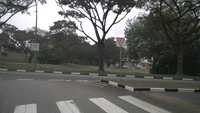
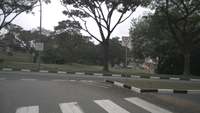
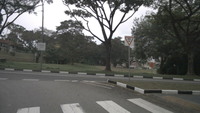
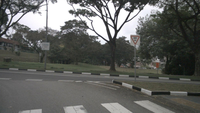
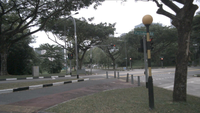
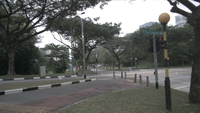
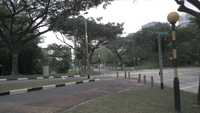
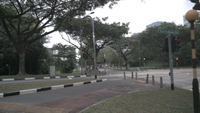
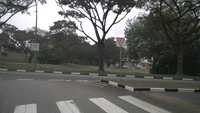
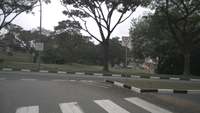
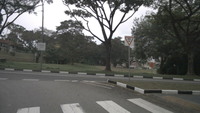
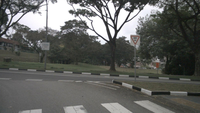

=== nuScenes CAM_FRONT 输入图像 ===


,,,
,,,
,,,
,,,

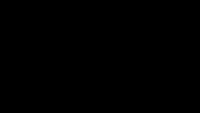
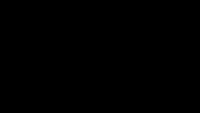
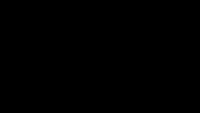
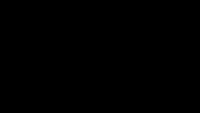
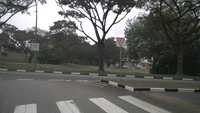
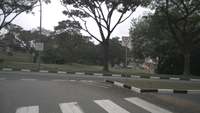
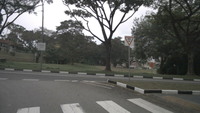
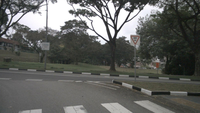
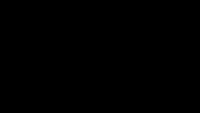
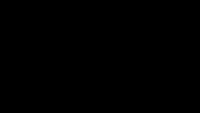
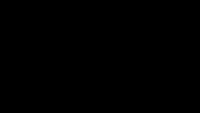
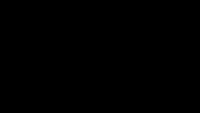
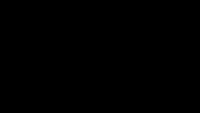
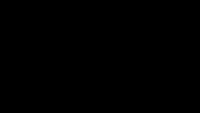
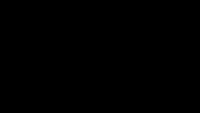
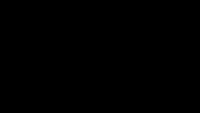

In [52]:
print("========== PhysicalAI-AV 数据集 ==========")
print("=== 原始输入图像 ===")
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)
print("=== Masked-30FOV 输入图像 ===")
mp.show_images(data_masked_30["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)
print("=== Masked-120FOV 输入图像 ===")
mp.show_images(data_masked_120["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

print("\n========== nuScenes 数据集 ==========")
print("=== nuScenes Full 输入图像 ===")
mp.show_images(data_nuscenes["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)
print("=== nuScenes CAM_FRONT 输入图像 ===")
mp.show_images(data_nuscenes_front["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

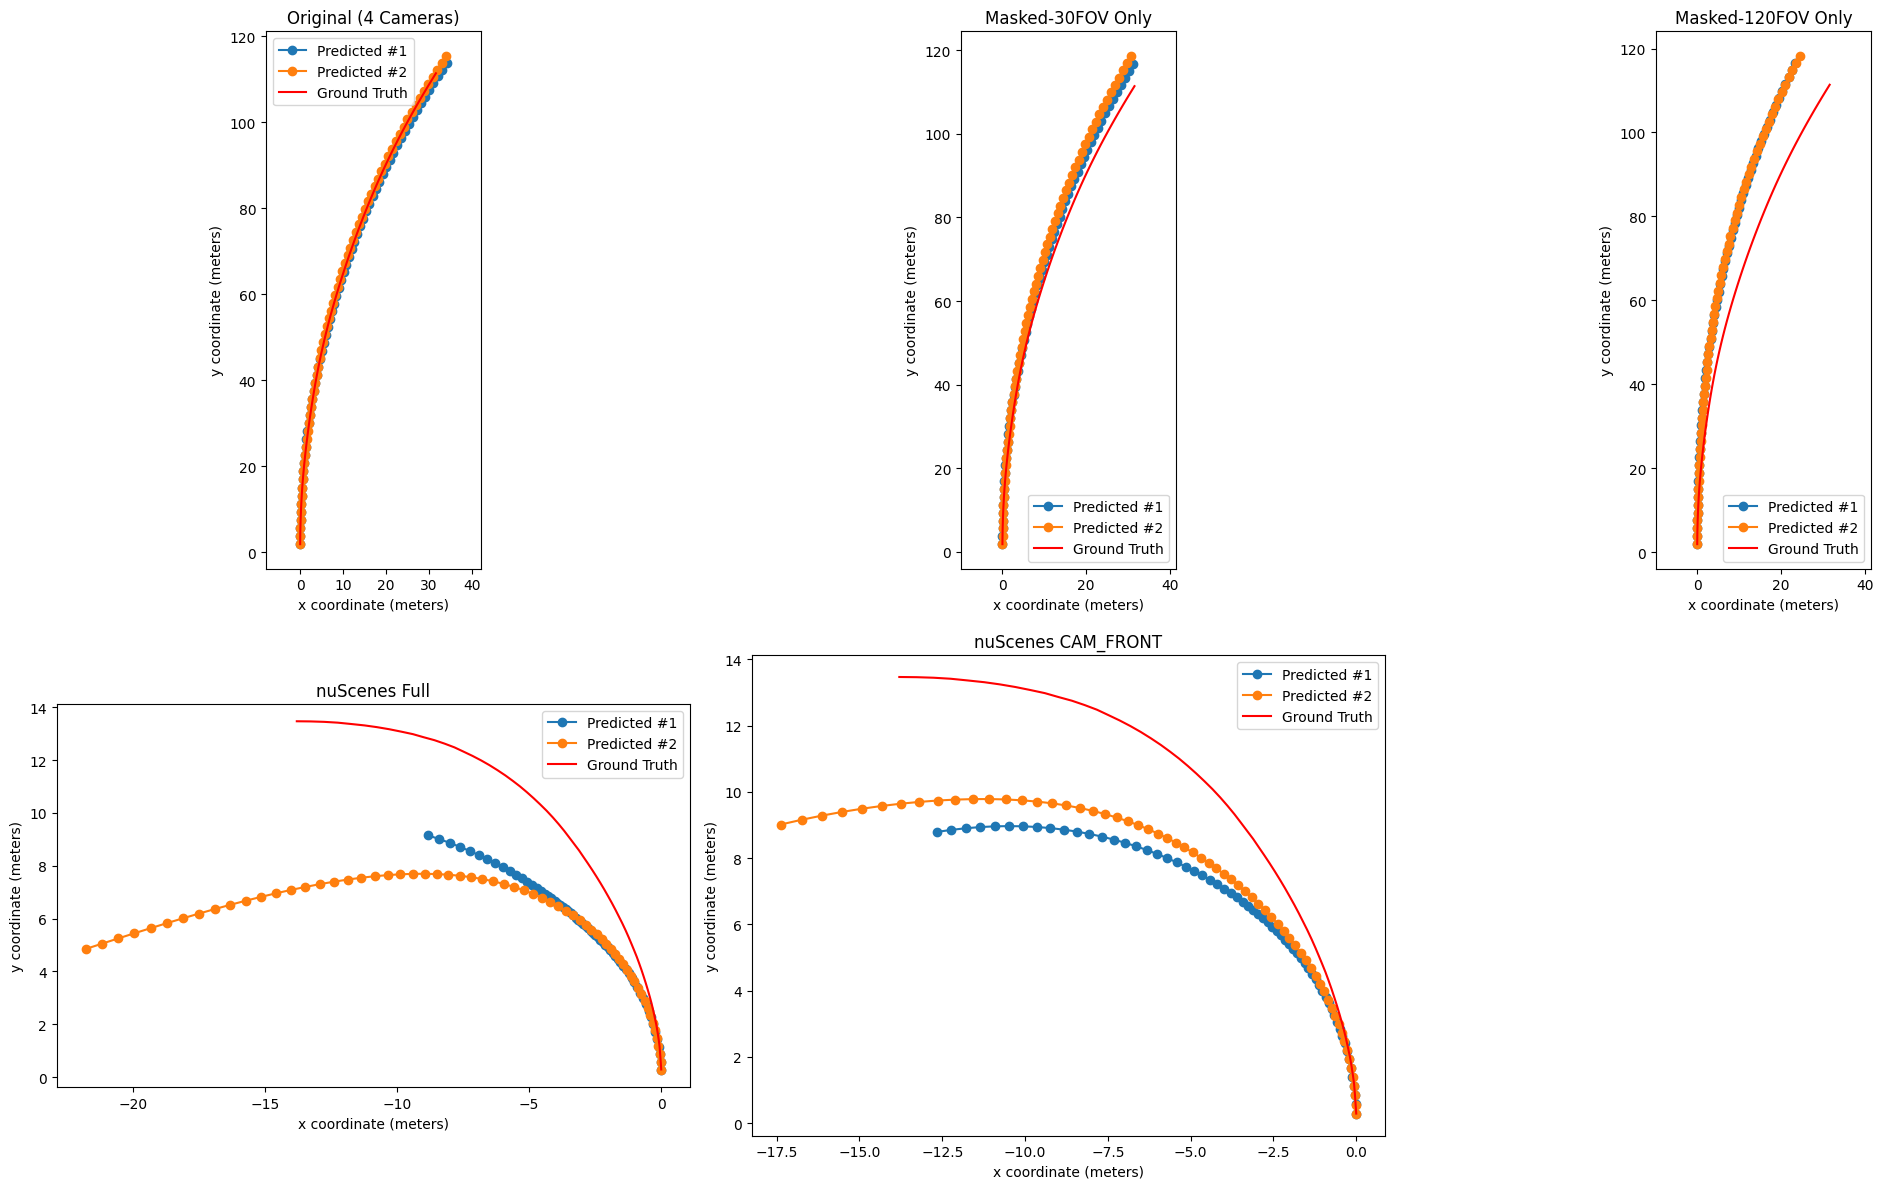

In [53]:
import matplotlib.pyplot as plt


def rotate_90cc(xy):
    """将 (x, y) 逆时针旋转 90 度 -> (y, -x)"""
    return np.stack([-xy[1], xy[0]], axis=0)


gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
gt_xy_ns = data_nuscenes["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Row 1: PhysicalAI-AV
configs_row1 = [
    (axes[0, 0], pred_xyz,      gt_xy,    "Original (4 Cameras)"),
    (axes[0, 1], pred_xyz_m30,  gt_xy,    "Masked-30FOV Only"),
    (axes[0, 2], pred_xyz_m120, gt_xy,    "Masked-120FOV Only"),
]
# Row 2: nuScenes
configs_row2 = [
    (axes[1, 0], pred_xyz_ns_full, gt_xy_ns, "nuScenes Full"),
    (axes[1, 1], pred_xyz_ns,      gt_xy_ns, "nuScenes CAM_FRONT"),
]
# Hide unused subplot
axes[1, 2].set_visible(False)

for ax, pxyz, gt, title in configs_row1 + configs_row2:
    gt_rot = rotate_90cc(gt)
    for i in range(pxyz.shape[2]):
        pred_xy = pxyz.cpu()[0, 0, i, :, :2].T.numpy()
        ax.plot(*rotate_90cc(pred_xy), "o-", label=f"Predicted #{i+1}")
    ax.plot(*gt_rot, "r-", label="Ground Truth")
    ax.set_title(title)
    ax.set_ylabel("y coordinate (meters)")
    ax.set_xlabel("x coordinate (meters)")
    ax.legend(loc="best")
    ax.set_aspect("equal")

    # Pad the smaller axis range to avoid compression
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]
    min_range = 0.4 * max(x_range, y_range)
    if x_range < min_range:
        x_center = (xlim[0] + xlim[1]) / 2
        ax.set_xlim(x_center - min_range / 2, x_center + min_range / 2)
    if y_range < min_range:
        y_center = (ylim[0] + ylim[1]) / 2
        ax.set_ylim(y_center - min_range / 2, y_center + min_range / 2)

plt.tight_layout()
plt.show()

In [54]:
gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
gt_xy_ns = data_nuscenes["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()

results = [
    ("Original (4 cameras)",  pred_xyz,         gt_xy),
    ("Masked-30FOV",          pred_xyz_m30,     gt_xy),
    ("Masked-120FOV",         pred_xyz_m120,    gt_xy),
    ("nuScenes Full",         pred_xyz_ns_full, gt_xy_ns),
    ("nuScenes CAM_FRONT",    pred_xyz_ns,      gt_xy_ns),
]
for label, pxyz, gt in results:
    pxy = pxyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
    diff = np.linalg.norm(pxy - gt[None, ...], axis=1).mean(-1)
    print(f"{label:25s} minADE: {diff.min():.4f} meters")

Original (4 cameras)      minADE: 1.3555 meters
Masked-30FOV              minADE: 2.0194 meters
Masked-120FOV             minADE: 4.1215 meters
nuScenes Full             minADE: 3.0937 meters
nuScenes CAM_FRONT        minADE: 1.8833 meters
